In [71]:
import pandas as pd 
import numpy as np

In [72]:
df = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv?utm_source=chatgpt.com')
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [74]:
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

In [75]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


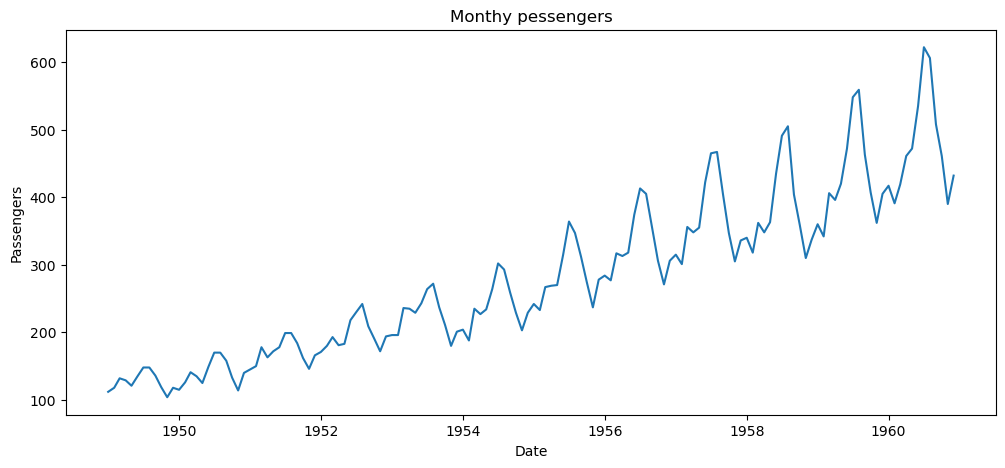

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df['Passengers'])
plt.title('Monthy pessengers')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.show()

In [77]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

In [78]:
scaled_data

array([[0.01544402],
       [0.02702703],
       [0.05405405],
       [0.04826255],
       [0.03281853],
       [0.05984556],
       [0.08494208],
       [0.08494208],
       [0.06177606],
       [0.02895753],
       [0.        ],
       [0.02702703],
       [0.02123552],
       [0.04247104],
       [0.07142857],
       [0.05984556],
       [0.04054054],
       [0.08687259],
       [0.12741313],
       [0.12741313],
       [0.1042471 ],
       [0.05598456],
       [0.01930502],
       [0.06949807],
       [0.07915058],
       [0.08880309],
       [0.14285714],
       [0.11389961],
       [0.13127413],
       [0.14285714],
       [0.18339768],
       [0.18339768],
       [0.15444015],
       [0.11196911],
       [0.08108108],
       [0.11969112],
       [0.12934363],
       [0.14671815],
       [0.17181467],
       [0.14864865],
       [0.15250965],
       [0.22007722],
       [0.24324324],
       [0.26640927],
       [0.2027027 ],
       [0.16795367],
       [0.13127413],
       [0.173

In [79]:
# create dataset
def create_dataset(data, time_step = 15):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step, 0])
        y.append(data[time_step + 1, 0])

    return np.array(X), np.array(y)

time_step = 30

X, y = create_dataset(scaled_data)

In [81]:
X.shape, y.shape

((129, 15), (129,))

In [82]:
for i in range(3):
    print(f"Sequence {i}")
    print(X[i])
    print("Target:", y[i])
    print()

Sequence 0
[0.01544402 0.02702703 0.05405405 0.04826255 0.03281853 0.05984556
 0.08494208 0.08494208 0.06177606 0.02895753 0.         0.02702703
 0.02123552 0.04247104 0.07142857]
Target: 0.04054054054054054

Sequence 1
[0.02702703 0.05405405 0.04826255 0.03281853 0.05984556 0.08494208
 0.08494208 0.06177606 0.02895753 0.         0.02702703 0.02123552
 0.04247104 0.07142857 0.05984556]
Target: 0.04054054054054054

Sequence 2
[0.05405405 0.04826255 0.03281853 0.05984556 0.08494208 0.08494208
 0.06177606 0.02895753 0.         0.02702703 0.02123552 0.04247104
 0.07142857 0.05984556 0.04054054]
Target: 0.04054054054054054



In [83]:
# convert to pytorch tensor 
import torch
X =  torch.FloatTensor(X)
y = torch.FloatTensor(y)

X.shape

torch.Size([129, 15])

In [84]:
from torch.utils.data import TensorDataset, DataLoader 

dataset = TensorDataset(X, y)
dataloader = DataLoader(
    dataset,
    batch_size = 16,
    shuffle=True
)


In [86]:
for X, y in dataloader:
    print(f"X shape {X.shape}, {y.shape}")
    print(f"X {X}")
    print(f"y {y}")

X shape torch.Size([16, 15]), torch.Size([16])
X tensor([[0.0598, 0.0849, 0.0849, 0.0618, 0.0290, 0.0000, 0.0270, 0.0212, 0.0425,
         0.0714, 0.0598, 0.0405, 0.0869, 0.1274, 0.1274],
        [0.0695, 0.0792, 0.0888, 0.1429, 0.1139, 0.1313, 0.1429, 0.1834, 0.1834,
         0.1544, 0.1120, 0.0811, 0.1197, 0.1293, 0.1467],
        [0.0849, 0.0618, 0.0290, 0.0000, 0.0270, 0.0212, 0.0425, 0.0714, 0.0598,
         0.0405, 0.0869, 0.1274, 0.1274, 0.1042, 0.0560],
        [0.1197, 0.1293, 0.1467, 0.1718, 0.1486, 0.1525, 0.2201, 0.2432, 0.2664,
         0.2027, 0.1680, 0.1313, 0.1737, 0.1776, 0.1776],
        [0.4073, 0.5019, 0.4691, 0.4015, 0.3282, 0.2568, 0.3359, 0.3475, 0.3340,
         0.4112, 0.4035, 0.4131, 0.5212, 0.5965, 0.5811],
        [0.5792, 0.4923, 0.3977, 0.4498, 0.4942, 0.4595, 0.5830, 0.5637, 0.6100,
         0.7104, 0.8571, 0.8784, 0.6931, 0.5849, 0.4981],
        [0.7471, 0.7741, 0.5792, 0.4923, 0.3977, 0.4498, 0.4942, 0.4595, 0.5830,
         0.5637, 0.6100, 0.7104, 0.8

In [92]:
# build model

# LSTM
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size=hidden_size, 
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)

        out = out[:, -1, :] 
        out = self.fc(out)

        return out

In [93]:
lstm = nn.LSTM(
            input_size = 1,
            hidden_size=64, 
            num_layers=2,
            batch_first=True
        )

output , (h_n, c_n) = lstm(X.unsqueeze(-1))

In [94]:
output.shape

torch.Size([1, 15, 64])

In [95]:
output

tensor([[[ 2.8665e-02,  6.2314e-03, -9.7014e-03,  4.8677e-03, -2.2338e-02,
           3.9209e-02,  6.5212e-03,  4.1844e-02,  9.9601e-03,  1.8280e-02,
          -1.7578e-03, -5.5743e-02, -2.8513e-02, -7.6249e-03,  4.4258e-03,
           3.0667e-02,  6.3625e-03, -2.9078e-02, -8.5517e-03,  5.8207e-03,
           1.8240e-02, -1.0481e-02,  2.0649e-02, -1.1518e-02,  1.9406e-02,
           1.8771e-02,  1.7042e-02,  1.0442e-02, -2.7373e-02,  2.2893e-02,
          -2.7621e-02,  2.9937e-02, -2.8707e-02,  2.3666e-03,  1.3277e-02,
           6.3854e-03,  1.3141e-02,  3.8925e-02, -1.6584e-02,  1.7048e-02,
           5.8336e-02,  5.5599e-02,  1.7245e-02,  9.0837e-03, -3.4976e-02,
          -7.3356e-03,  4.6673e-02, -2.5495e-02,  5.2791e-02,  9.3200e-03,
          -6.3786e-03, -1.8068e-02,  4.1407e-02, -1.3188e-02,  3.2080e-02,
           4.2345e-03, -2.9997e-02, -2.1368e-03, -3.6319e-02,  1.6051e-02,
           4.3958e-03,  7.9302e-03,  3.2652e-02, -3.3720e-02],
         [ 4.0463e-02,  8.5920e-03, -

In [96]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

lstm_model = LSTMModel().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

In [100]:
EPOCHS = 20

for epoch in range(EPOCHS):

    lstm_model.train()

    epoch_loss = 0

    for X_batch, y_batch in dataloader:

        X_batch = X_batch.unsqueeze(-1).to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = lstm_model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {epoch_loss/len(dataloader):.6f}"
    )

Epoch [1/20] Loss: 0.000094
Epoch [2/20] Loss: 0.000047
Epoch [3/20] Loss: 0.000018
Epoch [4/20] Loss: 0.000006
Epoch [5/20] Loss: 0.000002
Epoch [6/20] Loss: 0.000001
Epoch [7/20] Loss: 0.000000
Epoch [8/20] Loss: 0.000000
Epoch [9/20] Loss: 0.000000
Epoch [10/20] Loss: 0.000000
Epoch [11/20] Loss: 0.000000
Epoch [12/20] Loss: 0.000000
Epoch [13/20] Loss: 0.000000
Epoch [14/20] Loss: 0.000000
Epoch [15/20] Loss: 0.000000
Epoch [16/20] Loss: 0.000000
Epoch [17/20] Loss: 0.000000
Epoch [18/20] Loss: 0.000000
Epoch [19/20] Loss: 0.000000
Epoch [20/20] Loss: 0.000000
